<a href="https://colab.research.google.com/github/nieiamsi/my-first-repo/blob/main/Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('/content/Student_performance_data _.csv')

In [6]:
print(df.head())

   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929196         2.0  
1             0  3

In [28]:
print('Missing values per column:')
print(df.isnull().sum())
print(df.info())

Missing values per column:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
Study_Group          0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   

In [27]:
avg_grade = df['GPA'].mean()
print(f"The average grade in this dataset is: {avg_grade:.2f}")

The average grade in this dataset is: 1.91


In [31]:
avg_time = df['StudyTimeWeekly'].mean()
print(f'The average study time hour in this dataset is: {avg_time:.2f}')

The average study time hour in this dataset is: 9.77


In [13]:
df['Study_Group']=np.where(df['StudyTimeWeekly']>10, 'High Study', 'Low Study')

In [16]:
comparison = df.groupby('Study_Group')['GPA'].mean()
print(comparison)

Study_Group
High Study    2.048585
Low Study     1.773450
Name: GPA, dtype: float64


In [19]:
correlation = np.corrcoef(df['StudyTimeWeekly'], df['GPA'])[0, 1]
print(f"Correlation between study and grades: {correlation:.2f}")

Correlation between study and grades: 0.18


/tmp/ipykernel_975/2614018023.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison.index, y=comparison.values, palette='viridis')


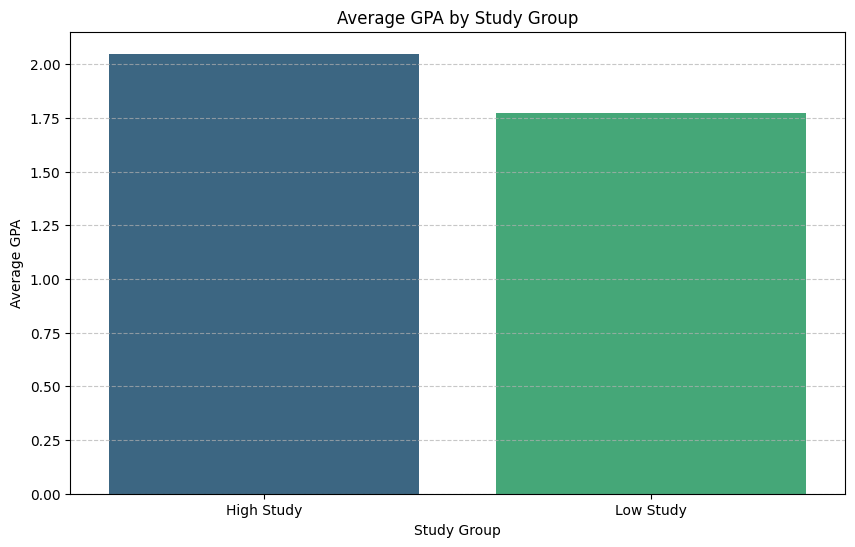

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(x=comparison.index, y=comparison.values, palette='viridis')
plt.title('Average GPA by Study Group')
plt.xlabel('Study Group')
plt.ylabel('Average GPA')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('average_gpa_by_study_group.png')
plt.show()

<Figure size 1000x600 with 0 Axes>

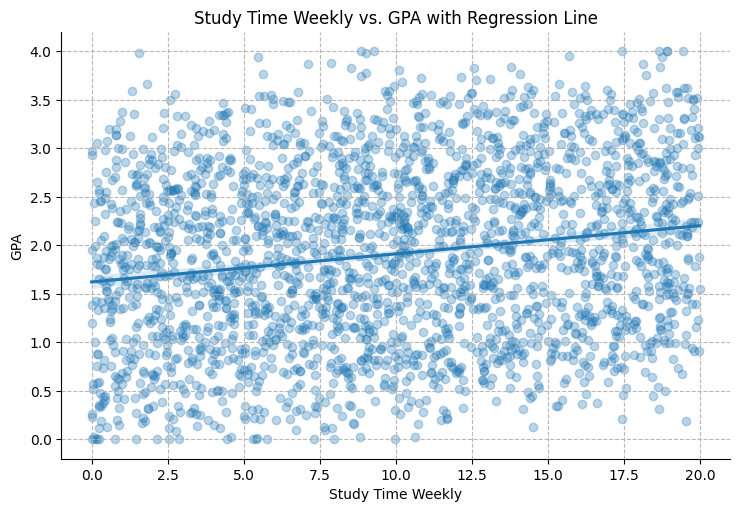

In [30]:
plt.figure(figsize=(10, 6))
sns.lmplot(x='StudyTimeWeekly', y='GPA', data=df, aspect=1.5, scatter_kws={'alpha':0.3})
plt.title('Study Time Weekly vs. GPA with Regression Line')
plt.xlabel('Study Time Weekly')
plt.ylabel('GPA')
plt.grid(True, linestyle='--', alpha=0.9)
plt.savefig('study_time_vs_gpa_with_regression.png')
plt.show()